In [1]:
import numpy as np
import pandas as pd
import h5py
from astropy.io import fits
import warnings
from tqdm import tqdm
from matplotlib import pyplot as plt

In [8]:
def read_quasars_from_hdf5(file_path):
    quasar_list = []
    with h5py.File(file_path, "r") as hdf:
        for group_name in hdf.keys():
            group = hdf[group_name]
            quasar = {"object_id": group_name}
            for key, value in group.attrs.items():
                quasar[key] = value
            for sub_group_name in group.keys():
                sub_group = group[sub_group_name]
                quasar[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
            quasar_list.append(quasar)
    return quasar_list


filters = {"u": 0, "g": 1, "r": 2, "i": 3, "z": 4, "y": 5} # harcoded filter order for SDSS


def populate_sdss_fields(objs, progress_bar=False):
    print(f"Populating SDSS fields: {len(objs)}", flush=True)
    cat = pd.read_parquet(f"data/S82/Catalog.parquet").set_index('idx')
    hdul = fits.open('data/dr16q_prop_May01_2024.fits')
    fits_data = hdul[1].data  # Assuming the data is in the first extension    
    fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    
    for d in tqdm(objs, desc="Populating SDSS fields", disable=(not progress_bar)):
        obj = cat.loc[cat['objectId'] == d['object_id']].iloc[0]
        i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
        if len(i) == 0:
            print(f"Warning: {d['sdss_name']} not found in SDSS data")
            return d

        i = i[0]
        # if np.any(fits_data_2['PSFFLUX'][i,:] <= 0):
        #     #print(f"Warning: {d['sdss_name']} has non-positive PSFFLUX values")
        #     continue
        
        d['z'] = obj['Z_SYS']
        d['M_i'] = fits_data_2['M_I'][i]
        d['sdss_name'] = fits_data['SDSS_NAME'][i]  # Extract SDSS_NAME
        d['ebv'] = fits_data['EBV'][i]
        d['EXTINCTION'] = np.mean(fits_data_2['EXTINCTION'][i])
        d['FHOST_5100'] = fits_data['FHOST_5100'][i]
        d['SN_MEDIAN_ALL'] = fits_data['SN_MEDIAN_ALL'][i]
    return objs

objs = read_quasars_from_hdf5("data/may8_lc_all.h5")
#objs = read_quasars_from_hdf5("data/july8_sdss_objs_rest_length_rf_exactly2000.h5")
print(len(objs))


sdss_objs = populate_sdss_fields(objs, progress_bar=True)
#sdss_objs = [obj for obj in sdss_objs if obj.get('M_i', np.inf) < 0]
print(len(objs))
print(len(sdss_objs))

import h5py

with h5py.File('data/aug4_sdss_objs_populated.h5', 'w') as hdf:
    for obj in sdss_objs:
        group = hdf.create_group(obj['object_id'])
        # Save attributes
        for key, value in obj.items():
            if isinstance(value, (int, float, str, np.integer, np.floating)):
                group.attrs[key] = value
        # Save nested dicts (e.g., times, mags, magerrs)
        for key, value in obj.items():
            if isinstance(value, dict):
                sub_group = group.create_group(key)
                for sub_key, sub_value in value.items():
                    sub_group.create_dataset(sub_key, data=np.array(sub_value))

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'data/may8_lc_all.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [7]:
sdss_objs_loaded = []
with h5py.File('data/aug4_sdss_objs_populated.h5', 'r') as hdf:
    for group_name in hdf.keys():
        group = hdf[group_name]
        obj = {'object_id': group_name}
        # Load attributes
        for key, value in group.attrs.items():
            obj[key] = value
        # Load nested dicts
        for sub_group_name in group.keys():
            sub_group = group[sub_group_name]
            obj[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
        sdss_objs_loaded.append(obj)
print(len(sdss_objs_loaded))


0


In [4]:
selected_objs = [obj for obj in sdss_objs_loaded if ((obj['ebv'] < 0.05) and (obj['SN_MEDIAN_ALL'] > 3))]
print(f"Number of selected objects with ebv < 0.05: {len(selected_objs)}")

Number of selected objects with ebv < 0.05: 0


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import median_abs_deviation as mad
from tqdm import tqdm

def reject_outliers_moving_window(times, mags, mag_errs, window_size=6, sigma_thresh=2.5):
    mags = np.array(mags)
    times = np.array(times)
    mag_errs = np.array(mag_errs)

    if len(mags) < 2 * window_size + 1:
        return times, mags, mag_errs

    mask = np.ones(len(mags), dtype=bool)
    for i in range(len(mags)):
        if i < window_size or i >= len(mags) - window_size:
            continue
        window = mags[i - window_size:i + window_size + 1]
        window_mad = mad(window, nan_policy='omit')
        window_mean = np.nanmean(window)

        if window_mad == 0:
            continue
        if np.abs(mags[i] - window_mean) > sigma_thresh * window_mad:
            mask[i] = False

    return times[mask], mags[mask], mag_errs[mask]

def gap_aligned_bins(times, bin_width=365.0):
    times = np.sort(times)
    if len(times) == 0:
        return np.array([0, bin_width])

    gaps = np.diff(times)
    large_gaps = np.where(gaps > 180)[0]

    bin_edges = []

    if len(large_gaps) > 0:
        first_cluster_end = times[large_gaps[0]]
        start_time = times[0] - bin_width/2
        while start_time < first_cluster_end:
            bin_edges.append(start_time)
            start_time += bin_width
        start_time = times[large_gaps[0]+1] - bin_width/2
    else:
        start_time = times[0] - bin_width/2

    while start_time <= times[-1] + bin_width:
        bin_edges.append(start_time)
        start_time += bin_width

    return np.array(bin_edges)

def compute_binned_chi2(times, mags, mag_errs, bin_edges):
    if len(times) == 0:
        return np.nan, np.array([]), np.array([])

    bin_indices = np.digitize(times, bin_edges) - 1
    bin_indices = np.clip(bin_indices, 0, len(bin_edges) - 2)

    bin_means = np.full(len(bin_edges) - 1, np.nan)
    bin_errors = np.full(len(bin_edges) - 1, np.nan)

    for b in range(len(bin_edges) - 1):
        mask = bin_indices == b
        if np.sum(mask) == 0:
            continue
        w = 1.0 / mag_errs[mask] ** 2
        bin_means[b] = np.sum(mags[mask] * w) / np.sum(w)
        bin_errors[b] = np.sqrt(1.0 / np.sum(w))

    valid_bins = ~np.isnan(bin_means)
    if np.sum(valid_bins) < 2:
        return np.nan, bin_means, bin_errors

    # Reduced chi-square across bins using bin errors
    weighted_mean = np.average(bin_means[valid_bins], weights=1/bin_errors[valid_bins]**2)
    chi_sq = np.sum(((bin_means[valid_bins] - weighted_mean) / bin_errors[valid_bins])**2)
    chi_sq_red = chi_sq / (np.sum(valid_bins) - 1)

    return chi_sq_red, bin_means, bin_errors

def rank_and_plot_light_curves(light_curves, save_dir="lc_plots"):
    results = []
    for lc_data in tqdm(light_curves, desc="Ranking light curves (gap-aligned bins)"):
        object_id = lc_data['object_id']
        z = lc_data.get('z', 0.0)

        g_times = np.array(lc_data['times'].get('g', []))
        g_mags = np.array(lc_data['mags'].get('g', []))
        g_errs = np.array(lc_data['magerrs'].get('g', []))

        g_times, g_mags, g_errs = reject_outliers_moving_window(g_times, g_mags, g_errs)

        if len(g_times) < 2:
            results.append(dict(object_id=object_id, chi_sq_g=np.nan))
            continue

        bin_edges = gap_aligned_bins(g_times)
        chi_sq_g, bin_means_g, bin_errs_g = compute_binned_chi2(g_times, g_mags, g_errs, bin_edges)

        all_times = np.concatenate([lc_data['times'][b] for b in lc_data['times']])
        all_mags = np.concatenate([lc_data['mags'][b] for b in lc_data['mags']])
        all_errs = np.concatenate([lc_data['magerrs'][b] for b in lc_data['magerrs']])

        chi_sq_all, _, _ = compute_binned_chi2(all_times, all_mags, all_errs, bin_edges)

        # save_lc_plot(object_id, lc_data['times'], lc_data['mags'], lc_data['magerrs'],
        #              chi_sq_g, chi_sq_all, bin_edges, bin_means_g, bin_errs_g, z, save_dir)

        results.append(dict(object_id=object_id, chi_sq_g=chi_sq_g, chi_sq_all=chi_sq_all))

    return sorted(results, key=lambda x: np.nan_to_num(x['chi_sq_g'], nan=-np.inf), reverse=True)


results = rank_and_plot_light_curves(selected_objs, save_dir="lc_plots")

Ranking light curves (gap-aligned bins): 0it [00:00, ?it/s]


In [15]:
def save_lc_plot(object_id, times_dict, mags_dict, magerrs_dict,
                 chi_sq_g, chi_sq_all, bin_edges, bin_means_g, bin_errs_g, z, save_dir="lc_plots"):
    os.makedirs(save_dir, exist_ok=True)
    plt.figure(figsize=(10, 6))
    colors = {"u": "tab:blue", "g": "tab:green", "r": "tab:orange", "i": "tab:red", "z": "tab:brown"}

    for band in ['g']:#["u", "g", "r", "i", "z"]:
        if len(times_dict.get(band, [])) == 0:
            continue
        plt.errorbar(times_dict[band], mags_dict[band], yerr=magerrs_dict[band],
                     fmt='o', ms=4, color=colors[band], label=f"{band}-band", alpha=0.7)

    for edge in bin_edges:
        plt.axvline(edge, color='gray', ls='--', alpha=0.4)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    mask = ~np.isnan(bin_means_g)
    plt.errorbar(bin_centers[mask], bin_means_g[mask], yerr=bin_errs_g[mask],
                 fmt='o', color="black", lw=3, ms=7, label="g-band bin mean")

    plt.gca().invert_yaxis()
    plt.xlabel("Time (MJD)")
    plt.ylabel("Magnitude")
    plt.title(f"Object {object_id}  Reduced χ²_g={chi_sq_g:.2f}, Reduced χ²_all={chi_sq_all:.2f} (z={z:.2f})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_dir}/object_{object_id}.png")
    plt.show()
    plt.close()

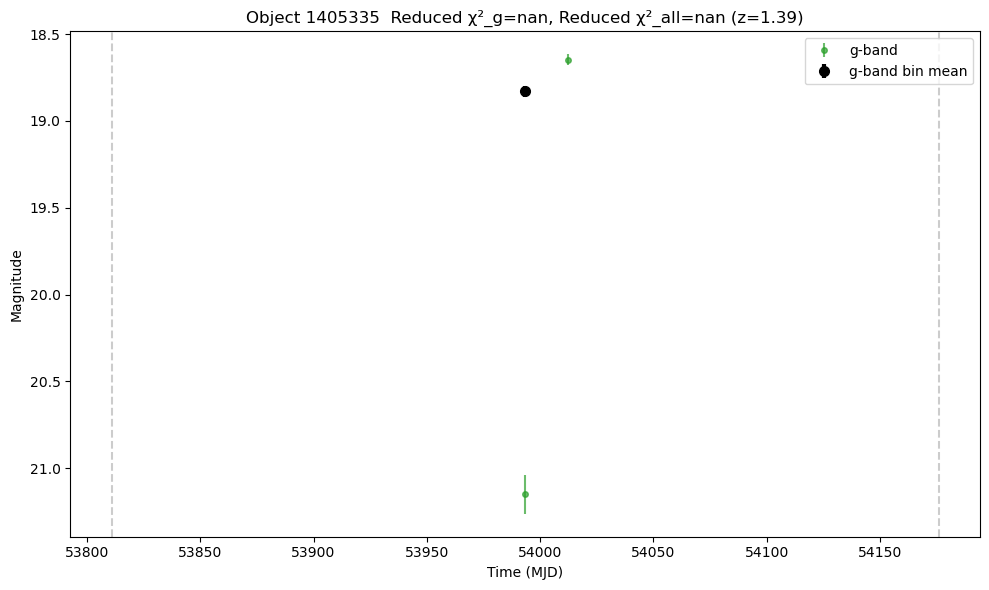

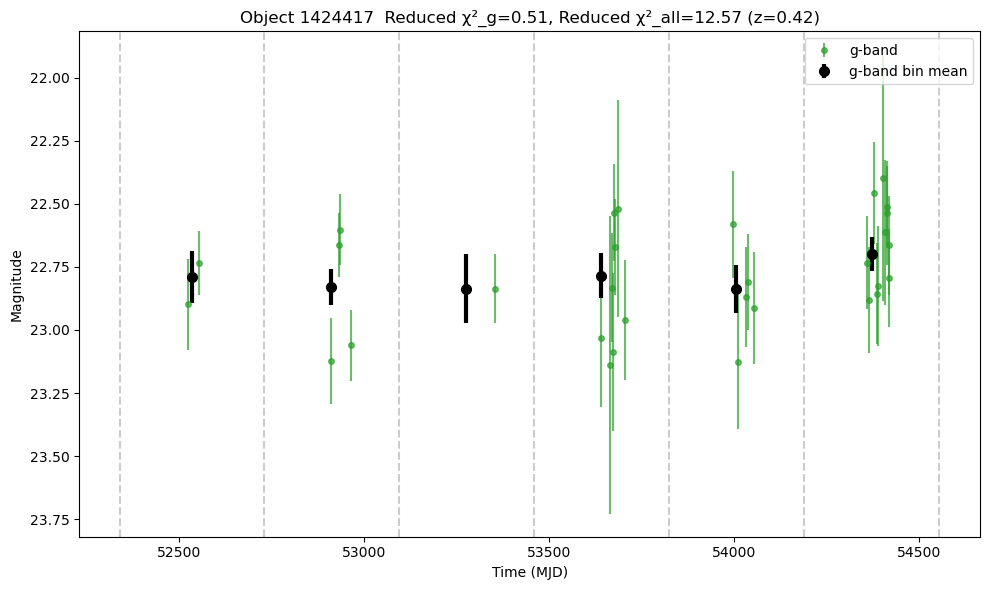

In [19]:
# Sort results by chi_sq_g in ascending order, then select every 100th up to 10 results
sorted_results = sorted(results, key=lambda x: np.nan_to_num(x['chi_sq_g'], nan=-np.inf))
selected_results = sorted_results[::10][:2]

for res in selected_results:
    object_id = res['object_id']
    chi_sq_g = res['chi_sq_g']
    chi_sq_all = res.get('chi_sq_all', np.nan)
    lc_data = next((obj for obj in selected_objs if obj['object_id'] == object_id), None)
    if lc_data is None:
        continue
    g_times = np.array(lc_data['times'].get('g', []))
    g_mags = np.array(lc_data['mags'].get('g', []))
    g_errs = np.array(lc_data['magerrs'].get('g', []))
    g_times, g_mags, g_errs = reject_outliers_moving_window(g_times, g_mags, g_errs)
    if len(g_times) < 2:
        continue
    bin_edges = gap_aligned_bins(g_times)
    _, bin_means_g, bin_errs_g = compute_binned_chi2(g_times, g_mags, g_errs, bin_edges)
    z = lc_data.get('z', 0.0)
    save_lc_plot(object_id, lc_data['times'], lc_data['mags'], lc_data['magerrs'],
                 chi_sq_g, chi_sq_all, bin_edges, bin_means_g, bin_errs_g, z, save_dir="lc_plots_ranked")

In [10]:
closest_result = min(results, key=lambda x: abs(x['chi_sq_g'] - 1))
closest_result

{'object_id': '1388434',
 'chi_sq_g': np.float64(1.571426072246323),
 'chi_sq_all': np.float64(5.515011739402251)}

In [20]:
filtered_results = [res for res in results if not np.isnan(res['chi_sq_g']) and res['chi_sq_g'] >= 10]
print(f"Number of results with chi_sq_g >= 10: {len(filtered_results)}")

Number of results with chi_sq_g >= 10: 13193


<>:18: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2353640/537292066.py:18: SyntaxWarning: invalid escape sequence '\c'
  ax[0].set_ylabel('Reduced $\chi^2_g$')
/tmp/ipykernel_2353640/537292066.py:19: SyntaxWarning: invalid escape sequence '\c'
  ax[0].set_title('Reduced $\chi^2_g$ vs Redshift')


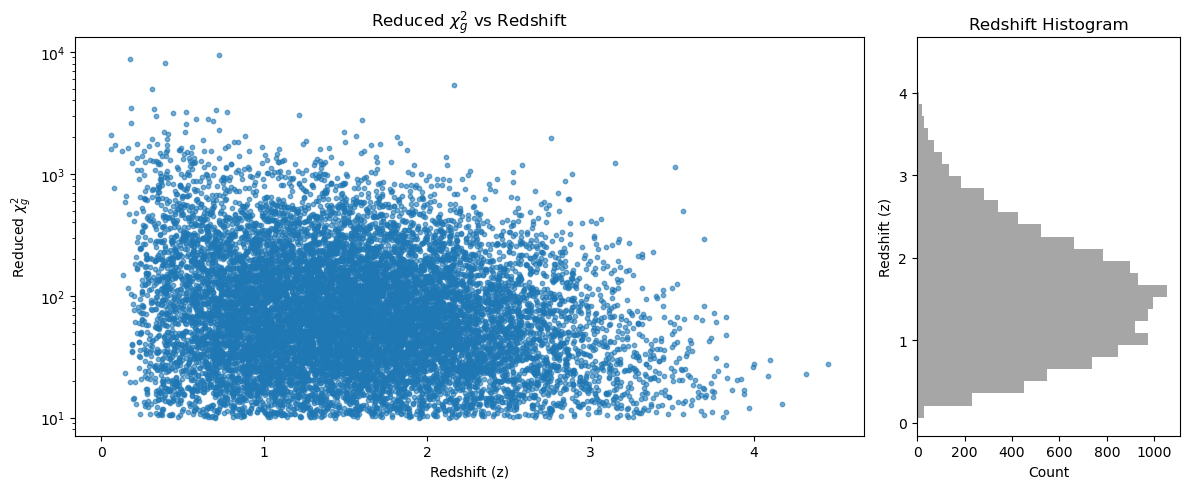

In [24]:
import matplotlib.pyplot as plt

# Extract chi_sq_g and redshift for all results with valid values
chi_sq_g = []
redshift = []
for res in filtered_results:
    if not np.isnan(res.get('chi_sq_g', np.nan)):
        obj = next((obj for obj in selected_objs if obj['object_id'] == res['object_id']), None)
        if obj is not None and 'z' in obj:
            chi_sq_g.append(res['chi_sq_g'])
            redshift.append(obj['z'])

fig, ax = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [3, 1]})

# Scatter plot
ax[0].scatter(redshift, chi_sq_g, alpha=0.6, s=10)
ax[0].set_xlabel('Redshift (z)')
ax[0].set_ylabel('Reduced $\chi^2_g$')
ax[0].set_title('Reduced $\chi^2_g$ vs Redshift')
ax[0].set_yscale('log')

# Histogram
ax[1].hist(redshift, bins=30, orientation='horizontal', color='gray', alpha=0.7)
ax[1].set_xlabel('Count')
ax[1].set_ylabel('Redshift (z)')
ax[1].set_title('Redshift Histogram')

plt.tight_layout()
plt.show()

In [9]:
df = pd.read_csv("data/csv/aug4_sample_chisqg10_ebv005sn3.csv")

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.to_csv("data/csv/aug4_sample_chisqg10_ebv005sn3.csv", index=False)

In [25]:
import pandas as pd

pd.DataFrame(filtered_results).to_csv("data/csv/aug4_sample_chisqg10_ebv005sn3.csv", index=False)

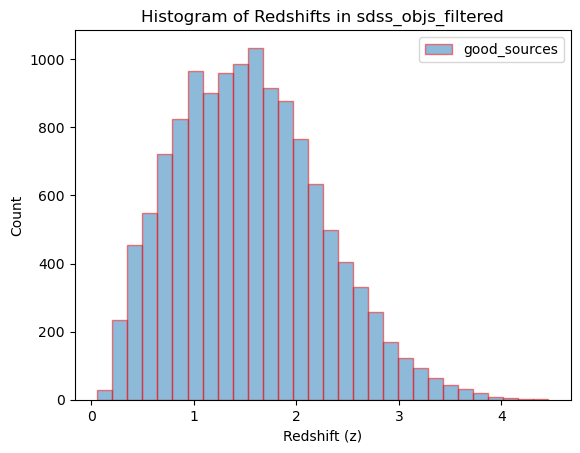

In [93]:
import matplotlib.pyplot as plt

plt.hist(good_sources['z'], bins=30, edgecolor='red', alpha=0.5, label='good_sources')
plt.legend()
plt.xlabel('Redshift (z)')
plt.ylabel('Count')
plt.title('Histogram of Redshifts in sdss_objs_filtered')
plt.show()

In [1]:
plt.hist(good_sources['M_i'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Absolute i-band Magnitude (M_i)')
plt.ylabel('Count')
plt.title('Histogram of M_i for good_sources')
plt.show()

NameError: name 'plt' is not defined

In [106]:
df.to_csv("data/may22_agn_all_ranked_chi2.csv", index=False)

In [107]:
df_sel = df[:4000]
df_sel = df_sel.sample(frac=1, random_state=42).reset_index(drop=True)
df_sel.to_csv("data/may22_agn_all_ranked_chi2_4000.csv", index=False)

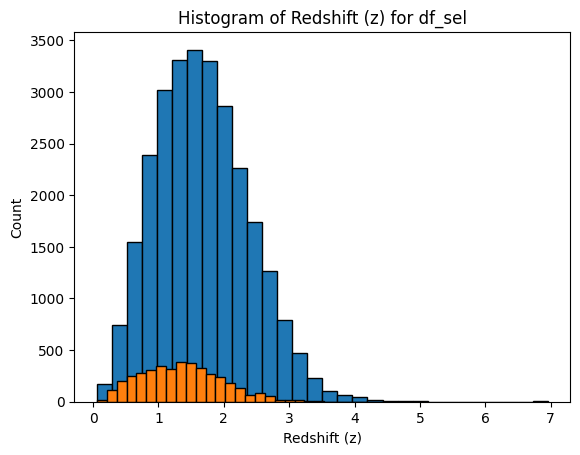

In [108]:
import matplotlib.pyplot as plt

plt.hist(df['z'], bins=30, edgecolor='black')
plt.hist(df_sel['z'], bins=30, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('Count')
plt.title('Histogram of Redshift (z) for df_sel')
plt.show()

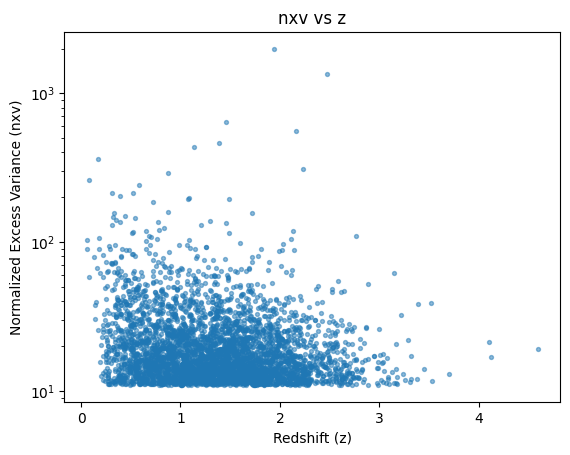

In [111]:
plt.scatter(df_sel['z'], df_sel['chi_sq'], alpha=0.5, s=8)
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Excess Variance (nxv)')
plt.title('nxv vs z')
plt.yscale('log')
plt.show()

In [87]:
df = df[df['ebv'] < 0.05]
len(df)

27769

In [64]:
d = df[df['total_observations'] > 800]
d

,object_id,robust_avg_nxv,total_observations,combined_score
28,1459958,0.001931,986,0.005780
66,1463119,0.000966,963,0.002882
78,1427359,0.000903,811,0.002627
88,1424290,0.000785,973,0.002344
108,1465974,0.000661,1060,0.001999
...,...,...,...,...
35723,1451585,0.000003,1612,0.000010
36016,1401309,0.000003,805,0.000009
36391,1385141,0.000002,1089,0.000006
36473,1464956,0.000002,1317,0.000005


In [65]:
d.to_csv('data/s82_lc_ranking.csv', index=False)